In [37]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [38]:
HSA = pd.read_csv('./Horizontal_Shoulder_Abduction.csv')
HA = pd.read_csv('./hip_abduction_coords.csv')
HH = pd.read_csv('./HipHig_coords.csv')

In [39]:

def calculateAngle(a, b, c):
    a = np.array(a)  
    b = np.array(b)  
    c = np.array(c) 

    radians = np.arctan2(c[1] - b[1], c[0] - b[0]) - np.arctan2(
        a[1] - b[1], a[0] - b[0]
    )
    angle = np.abs(radians * 180.0 / np.pi)

    if angle > 180.0:
        angle = 360 - angle

    return angle

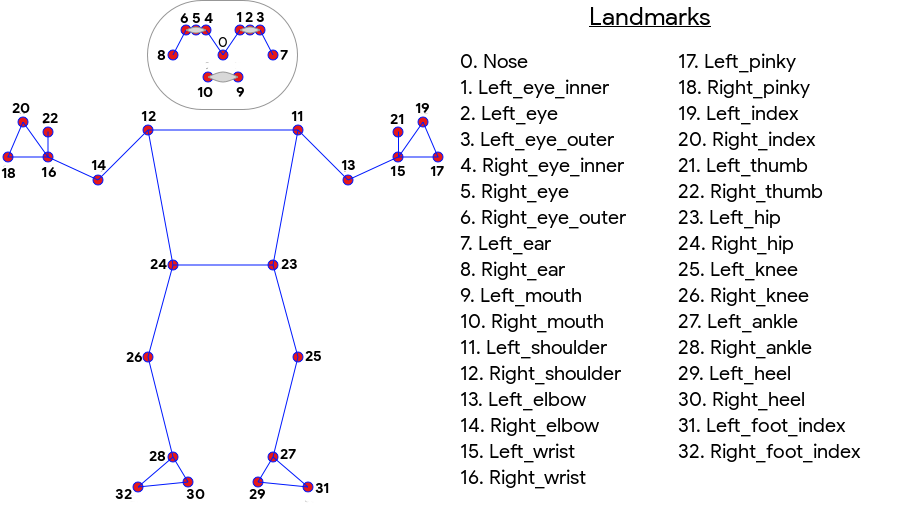

In [40]:
def extract_joint_coordinates(df):
    nose = []
    left_shoulder = []
    left_elbow = []
    left_wrist = []
    left_hip = []
    left_knee = []
    left_ankle = []
    left_heel = []
    right_shoulder = []
    right_elbow = []
    right_wrist = []
    right_hip = []
    right_knee = []
    right_ankle = []
    right_heel = []

    for i in range(len(df)):
        nose.append([df['x1'].values[i], df['y1'].values[i]])
        left_shoulder.append([df['x12'].values[i], df['y12'].values[i]])
        left_elbow.append([df['x14'].values[i], df['y14'].values[i]])
        left_wrist.append([df['x16'].values[i], df['y16'].values[i]])
        left_hip.append([df['x26'].values[i], df['y26'].values[i]])
        left_knee.append([df['x28'].values[i], df['y28'].values[i]])
        left_ankle.append([df['x30'].values[i], df['y30'].values[i]])
        left_heel.append([df['x32'].values[i], df['y32'].values[i]])
        right_shoulder.append([df['x13'].values[i], df['y13'].values[i]])
        right_elbow.append([df['x15'].values[i], df['y15'].values[i]])
        right_wrist.append([df['x17'].values[i], df['y17'].values[i]])
        right_hip.append([df['x27'].values[i], df['y27'].values[i]])
        right_knee.append([df['x29'].values[i], df['y29'].values[i]])
        right_ankle.append([df['x31'].values[i], df['y31'].values[i]])
        right_heel.append([df['x33'].values[i], df['y33'].values[i]])

    return nose, left_shoulder, left_elbow, left_wrist, left_hip, left_knee, left_ankle, left_heel, right_shoulder, right_elbow, right_wrist, right_hip, right_knee, right_ankle, right_heel

In [41]:
nose, left_shoulder, left_elbow, left_wrist, left_hip, left_knee, left_ankle, left_heel, right_shoulder, right_elbow, right_wrist, right_hip, right_knee, right_ankle, right_heel = extract_joint_coordinates(HH)

# Output
print("Nose:", nose[:5])
print("Left shoulder:", left_shoulder[:5])
print("Left elbow:", left_elbow[:5])
print("Left wrist:", left_wrist[:5])
print("Left hip:", left_hip[:5])
print("Left knee:", left_knee[:5])
print("Left ankle:", left_ankle[:5])
print("Left heel:", left_heel[:5])
print("Right shoulder:", right_shoulder[:5])
print("Right elbow:", right_elbow[:5])
print("Right wrist:", right_wrist[:5])
print("Right hip:", right_hip[:5])
print("Right knee:", right_knee[:5])
print("Right ankle:", right_ankle[:5])
print("Right heel:", right_heel[:5])

Nose: [[np.float64(0.495459676), np.float64(0.232345551)], [np.float64(0.481013685), np.float64(0.248531654)], [np.float64(0.474185646), np.float64(0.265292555)], [np.float64(0.467863232), np.float64(0.279249966)], [np.float64(0.46219936), np.float64(0.294757664)]]
Left shoulder: [[np.float64(0.532000601), np.float64(0.288610727)], [np.float64(0.520000577), np.float64(0.291247427)], [np.float64(0.514942706), np.float64(0.305573851)], [np.float64(0.511099517), np.float64(0.311719)], [np.float64(0.507692933), np.float64(0.321136147)]]
Left elbow: [[np.float64(0.55247736), np.float64(0.372218251)], [np.float64(0.546559453), np.float64(0.37046954)], [np.float64(0.543869615), np.float64(0.373263896)], [np.float64(0.542978406), np.float64(0.376076818)], [np.float64(0.542142391), np.float64(0.380506337)]]
Left wrist: [[np.float64(0.531913757), np.float64(0.450824738)], [np.float64(0.537399769), np.float64(0.45324263)], [np.float64(0.542753637), np.float64(0.455389947)], [np.float64(0.54726016

In [42]:
neck_angle = [(calculateAngle(left_shoulder[i], nose[i], left_hip[i]) + calculateAngle(right_shoulder[i], nose[i], right_hip[i])) / 2 for i in range(len(nose))]
left_elbow_angle = [calculateAngle(left_shoulder[i], left_elbow[i], left_wrist[i]) for i in range(len(left_shoulder))]
right_elbow_angle = [calculateAngle(right_shoulder[i], right_elbow[i], right_wrist[i]) for i in range(len(right_shoulder))]
left_shoulder_angle = [calculateAngle(left_elbow[i], left_shoulder[i], left_hip[i]) for i in range(len(left_elbow))]
right_shoulder_angle = [calculateAngle(right_elbow[i], right_shoulder[i], right_hip[i]) for i in range(len(right_elbow))]
left_hip_angle = [calculateAngle(left_shoulder[i], left_hip[i], left_knee[i]) for i in range(len(left_shoulder))]
right_hip_angle = [calculateAngle(right_shoulder[i], right_hip[i], right_knee[i]) for i in range(len(right_shoulder))]
left_knee_angle = [calculateAngle(left_hip[i], left_knee[i], left_ankle[i]) for i in range(len(left_hip))]
right_knee_angle = [calculateAngle(right_hip[i], right_knee[i], right_ankle[i]) for i in range(len(right_hip))]
left_ankle_angle = [calculateAngle(left_knee[i], left_ankle[i], left_heel[i]) for i in range(len(left_knee))]
right_ankle_angle = [calculateAngle(right_knee[i], right_ankle[i], right_heel[i]) for i in range(len(right_knee))]

print("Neck angle:", neck_angle)
print("Left elbow angle:", left_elbow_angle)
print("Right elbow angle:", right_elbow_angle)
print("Left shoulder angle:", left_shoulder_angle)
print("Right shoulder angle:", right_shoulder_angle)
print("Left hip angle:", left_hip_angle)
print("Right hip angle:", right_hip_angle)
print("Left knee angle:", left_knee_angle)
print("Right knee angle:", right_knee_angle)
print("Left ankle angle:", left_ankle_angle)
print("Right ankle angle:", right_ankle_angle)

Neck angle: [np.float64(24.781220419533767), np.float64(31.77707749872807), np.float64(35.870877197806124), np.float64(42.15971329133822), np.float64(47.48630755485217), np.float64(53.050436992269766), np.float64(56.404826342403155), np.float64(63.42388294354404), np.float64(67.1973762423832), np.float64(74.89204476998809), np.float64(79.64734017955554), np.float64(81.55253011066532), np.float64(83.47345774415723), np.float64(84.48924990300469), np.float64(69.804839063864), np.float64(45.84149307972894), np.float64(39.66767485314082), np.float64(33.048034763047184), np.float64(27.716439296935267), np.float64(24.19465559920302), np.float64(23.0796010395356), np.float64(54.04111837084376), np.float64(51.44005496246697), np.float64(48.45684832865058), np.float64(49.131226073963816), np.float64(48.27548062820854), np.float64(48.037191413027685), np.float64(45.933988241878154), np.float64(45.81680671841367), np.float64(43.57757815572037), np.float64(44.01622974227662), np.float64(43.1304020

In [43]:
def calculate_joint_angles(row):
    nose = [row['x1'], row['y1']]
    left_shoulder = [row['x12'], row['y12']]
    left_elbow = [row['x14'], row['y14']]
    left_wrist = [row['x16'], row['y16']]
    left_hip = [row['x26'], row['y26']]
    left_knee = [row['x28'], row['y28']]
    left_ankle = [row['x30'], row['y30']]
    left_heel = [row['x32'], row['y32']]
    right_shoulder = [row['x13'], row['y13']]
    right_elbow = [row['x15'], row['y15']]
    right_wrist = [row['x17'], row['y17']]
    right_hip = [row['x27'], row['y27']]
    right_knee = [row['x29'], row['y29']]
    right_ankle = [row['x31'], row['y31']]
    right_heel = [row['x33'], row['y33']]

    neck_angle = (calculateAngle(left_shoulder, nose, left_hip) + calculateAngle(right_shoulder, nose, right_hip)) / 2
    left_elbow_angle = calculateAngle(left_shoulder, left_elbow, left_wrist)
    right_elbow_angle = calculateAngle(right_shoulder, right_elbow, right_wrist)
    left_shoulder_angle = calculateAngle(left_elbow, left_shoulder, left_hip)
    right_shoulder_angle = calculateAngle(right_elbow, right_shoulder, right_hip)
    left_hip_angle = calculateAngle(left_shoulder, left_hip, left_knee)
    right_hip_angle = calculateAngle(right_shoulder, right_hip, right_knee)
    left_knee_angle = calculateAngle(left_hip, left_knee, left_ankle)
    right_knee_angle = calculateAngle(right_hip, right_knee, right_ankle)
    left_ankle_angle = calculateAngle(left_knee, left_ankle, left_heel)
    right_ankle_angle = calculateAngle(right_knee, right_ankle, right_heel)

    return pd.Series([neck_angle, left_elbow_angle, right_elbow_angle, left_shoulder_angle, right_shoulder_angle, left_hip_angle, right_hip_angle, left_knee_angle, right_knee_angle, left_ankle_angle, right_ankle_angle])

# 1. Horizental Shoulder Abduction

In [22]:
angle_columns = ['neck_angle', 'left_elbow_angle', 'right_elbow_angle', 'left_shoulder_angle', 'right_shoulder_angle', 'left_hip_angle', 'right_hip_angle', 'left_knee_angle', 'right_knee_angle', 'left_ankle_angle', 'right_ankle_angle']
HSA[angle_columns] = HSA.apply(calculate_joint_angles, axis=1)

scaler = MinMaxScaler()
scaled_angles = scaler.fit_transform(HSA[angle_columns])

scaled_angles_df = pd.DataFrame(scaled_angles, columns=angle_columns)

HSA = pd.concat([HSA, scaled_angles_df], axis=1)
HSA.to_csv("Horizental_Shoulder_Abduction_scaled_angles.csv", index=False)

In [23]:
HSA

,class,x1,y1,z1,v1,x2,y2,z2,v2,x3,...,left_elbow_angle,right_elbow_angle,left_shoulder_angle,right_shoulder_angle,left_hip_angle,right_hip_angle,left_knee_angle,right_knee_angle,left_ankle_angle,right_ankle_angle
0,HSA_correct_C,0.500722,0.143423,-0.115376,0.999998,0.506674,0.127892,-0.096351,0.999999,0.510353,...,0.682764,0.730064,0.136085,0.242943,0.905252,0.540004,0.836530,0.905863,0.989686,0.966244
1,HSA_correct_O,0.501870,0.144244,-0.134684,0.999999,0.506582,0.128032,-0.115288,0.999999,0.509927,...,0.689782,0.680322,0.256425,0.268025,0.877772,0.553141,0.838947,0.845660,0.989627,0.934956
2,HSA_correct_O,0.501907,0.144705,-0.149788,0.999999,0.506241,0.128131,-0.128687,0.999999,0.509277,...,0.818526,0.854956,0.378153,0.408922,0.859074,0.536068,0.861962,0.848604,0.980507,0.941186
3,HSA_correct_O,0.501462,0.143613,-0.289564,0.999997,0.506054,0.127437,-0.271445,0.999984,0.509138,...,0.881784,0.900657,0.426078,0.444596,0.806226,0.485886,0.848088,0.882252,0.981793,0.984958
4,HSA_correct_O,0.501724,0.141454,-0.399365,0.999992,0.506334,0.125832,-0.381765,0.999963,0.509482,...,0.901224,0.916801,0.440125,0.461784,0.796041,0.438205,0.841227,0.900626,0.989706,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
273,HSA_correct_C,0.528389,0.122619,-0.510843,0.999997,0.539113,0.111156,-0.479682,0.999987,0.543845,...,0.820804,0.849133,0.439194,0.414040,0.874292,0.726755,0.421443,0.714910,0.260654,0.448500
274,HSA_correct_C,0.528194,0.120979,-0.474052,0.999997,0.539450,0.109625,-0.447727,0.999993,0.544347,...,0.687217,0.753577,0.350153,0.347885,0.902515,0.759946,0.433844,0.701183,0.262392,0.476239
275,HSA_correct_C,0.526977,0.120843,-0.466031,0.999997,0.539432,0.109186,-0.437666,0.999995,0.544476,...,0.630851,0.580700,0.348334,0.232621,0.848001,0.806779,0.471436,0.657450,0.330730,0.472992
276,HSA_correct_C,0.524034,0.120691,-0.446017,0.999994,0.536911,0.109133,-0.416339,0.999993,0.542925,...,0.423689,0.115721,0.226625,0.169914,0.928005,0.720697,0.419143,0.656831,0.293495,0.479444


# HipAbduction - HA

In [36]:
angle_columns = ['neck_angle', 'left_elbow_angle', 'right_elbow_angle', 'left_shoulder_angle', 'right_shoulder_angle', 'left_hip_angle', 'right_hip_angle', 'left_knee_angle', 'right_knee_angle', 'left_ankle_angle', 'right_ankle_angle']
HA[angle_columns] = HA.apply(calculate_joint_angles, axis=1)

scaler = MinMaxScaler()
scaled_angles = scaler.fit_transform(HA[angle_columns])

scaled_angles_df = pd.DataFrame(scaled_angles, columns=angle_columns)

HA = pd.concat([HA, scaled_angles_df], axis=1)
HA.to_csv("hip_abduction_coords_with_scaled_angles.csv", index=False)
HA

,class,x1,y1,z1,v1,x2,y2,z2,v2,x3,...,left_elbow_angle,right_elbow_angle,left_shoulder_angle,right_shoulder_angle,left_hip_angle,right_hip_angle,left_knee_angle,right_knee_angle,left_ankle_angle,right_ankle_angle
0,HA_correct_down,0.482258,0.138999,-0.266800,0.999993,0.490019,0.120772,-0.249850,0.999979,0.493913,...,0.967279,0.352402,0.020707,0.574701,1.000000,0.882578,1.000000,1.000000,0.990803,0.981622
1,HA_correct_up,0.510111,0.137572,-0.255849,0.999994,0.517326,0.121104,-0.236690,0.999982,0.521081,...,0.990976,0.322407,0.000000,0.476290,0.989649,0.645011,0.962453,0.959452,0.894818,1.000000
2,HA_correct_up,0.509845,0.137760,-0.251229,0.999994,0.516653,0.120764,-0.232714,0.999983,0.520955,...,0.999821,0.323182,0.010210,0.425538,0.979421,0.589608,0.968135,0.862901,0.876348,0.889035
3,HA_correct_up,0.509054,0.137263,-0.239127,0.999994,0.515318,0.120010,-0.220493,0.999984,0.520301,...,0.984983,0.330714,0.026752,0.390318,0.975484,0.547616,0.975317,0.840386,0.878757,0.863656
4,HA_correct_up,0.507728,0.137230,-0.237230,0.999994,0.513732,0.119909,-0.219706,0.999982,0.518945,...,0.979912,0.339852,0.033750,0.362492,0.972691,0.511857,0.977790,0.905971,0.877859,0.889242
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,HA_correct_down,0.603740,0.167484,-0.333564,0.999670,0.616185,0.155186,-0.318608,0.999229,0.626221,...,0.409700,0.910300,0.786411,0.138376,0.938233,0.613975,0.499031,0.518510,0.307183,0.420121
199,HA_correct_down,0.602837,0.167550,-0.407905,0.999675,0.615250,0.155186,-0.384925,0.999235,0.625252,...,0.424295,0.909054,0.795922,0.156676,0.942377,0.615011,0.461794,0.506938,0.297091,0.418735
200,HA_correct_down,0.596407,0.167828,-0.545018,0.999693,0.607783,0.155556,-0.514456,0.999268,0.617595,...,0.475881,0.909345,0.854767,0.244867,0.975554,0.748339,0.336694,0.555236,0.297440,0.415960
201,HA_correct_down,0.588208,0.168046,-0.543695,0.999701,0.599146,0.156141,-0.510624,0.999269,0.609585,...,0.555730,0.929510,0.900559,0.322923,0.980621,0.879297,0.338399,0.606938,0.295254,0.515930


# HipHig

In [44]:
angle_columns = ['neck_angle', 'left_elbow_angle', 'right_elbow_angle', 'left_shoulder_angle', 'right_shoulder_angle', 'left_hip_angle', 'right_hip_angle', 'left_knee_angle', 'right_knee_angle', 'left_ankle_angle', 'right_ankle_angle']
HH[angle_columns] = HH.apply(calculate_joint_angles, axis=1)

scaler = MinMaxScaler()
scaled_angles = scaler.fit_transform(HH[angle_columns])

scaled_angles_df = pd.DataFrame(scaled_angles, columns=angle_columns)

HH = pd.concat([HH, scaled_angles_df], axis=1)
HH.to_csv("HipHig_with_scaled_angles.csv", index=False)
HH

,class,x1,y1,z1,v1,x2,y2,z2,v2,x3,...,left_elbow_angle,right_elbow_angle,left_shoulder_angle,right_shoulder_angle,left_hip_angle,right_hip_angle,left_knee_angle,right_knee_angle,left_ankle_angle,right_ankle_angle
0,HH_correct_up,0.495460,0.232346,-0.012427,0.999214,0.499850,0.218067,-0.029999,0.999084,0.501275,...,0.797856,0.780546,0.045990,0.046241,0.972947,0.983063,0.838525,0.917507,0.305020,0.303676
1,HH_correct_down,0.481014,0.248532,-0.018214,0.999297,0.484057,0.233193,-0.037008,0.999166,0.485566,...,0.838184,0.838974,0.081350,0.072906,0.995293,0.995837,0.844413,0.943557,0.329325,0.365235
2,HH_correct_down,0.474186,0.265293,-0.017055,0.999627,0.476055,0.250516,-0.036390,0.999558,0.477248,...,0.848685,0.838469,0.129547,0.111836,0.993947,0.981327,0.855452,0.919209,0.355040,0.372011
3,HH_correct_down,0.467863,0.279250,-0.019977,0.999772,0.469359,0.264307,-0.040694,0.999731,0.470442,...,0.855268,0.833372,0.159811,0.137960,0.979526,0.970110,0.860950,0.924011,0.362674,0.367714
4,HH_correct_down,0.462199,0.294758,-0.013296,0.999860,0.463218,0.280154,-0.034047,0.999835,0.464392,...,0.845407,0.812717,0.198181,0.169759,0.963556,0.955114,0.825025,0.930976,0.307709,0.417263
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
386,HH_correct_up,0.468470,0.184174,-0.179191,0.999962,0.485230,0.172330,-0.229517,0.999963,0.490077,...,0.519946,0.468399,0.558491,0.346130,0.869333,0.943679,0.579643,0.702525,0.184483,0.220489
387,HH_correct_up,0.481773,0.173939,-0.201235,0.999948,0.500032,0.161907,-0.254076,0.999951,0.504155,...,0.452885,0.455892,0.527028,0.318132,0.884902,0.934051,0.567435,0.713758,0.174788,0.242365
388,HH_correct_up,0.490718,0.171957,-0.223796,0.999904,0.508806,0.158674,-0.277614,0.999909,0.513441,...,0.403718,0.334862,0.497440,0.282964,0.903059,0.925647,0.520523,0.698203,0.165267,0.238338
389,HH_correct_up,0.500680,0.168881,-0.224457,0.999781,0.519862,0.155317,-0.270281,0.999783,0.524632,...,0.360288,0.471154,0.461714,0.164394,0.898613,0.936096,0.506898,0.719055,0.153769,0.253255
